In [4]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [5]:
path = "../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
protein_localization = np.load( path + 'protein_localization_dataset.npz')

In [6]:
investigate_dataset(protein_localization)

['X', 'y', 'genes']

Array shapes:
X shape: (9769, 12288, 6)
y shape: (9769, 12)
genes shape: (9769,)

First few y values: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 0. 1. 0. 0.]


In [7]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(protein_localization['X'], protein_localization['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (9769, 2048)


In [8]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 65.05%


In [9]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, protein_localization['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.857060,-3.787262,17.809710,9.046390,-4.547431,1.063632,-10.573202,-3.584456,-7.779973,4.624103,...,0.398317,-0.178126,0.616264,-0.968642,0.895690,-1.071394,1.569221,-1.075961,-0.266958,-0.354507
FGR,-10.732242,16.028654,-5.620865,-0.390532,0.572422,-7.165994,-3.192176,0.394430,5.179989,1.700039,...,0.334425,0.137181,0.199019,-0.050332,-0.396832,-0.590416,-0.447042,-0.416157,-0.188863,0.404374
CFH,7.006769,23.785324,-7.231854,9.518305,5.970861,5.529081,2.494767,-2.941073,-10.176371,6.325779,...,-0.114801,-1.062900,1.308990,0.402955,1.783213,-0.149868,0.396394,0.973839,1.324354,1.084882
GCLC,3.741430,16.818724,-5.728342,10.611600,1.751133,1.134791,0.392032,2.120358,-4.206367,-1.344799,...,-0.590011,-1.019814,-0.596991,0.039509,-0.473641,0.692558,-0.552554,0.225940,0.116807,1.300625
NFYA,16.261393,-2.448970,11.577350,-1.681753,-6.334575,6.198440,9.162395,2.846519,6.783524,-1.467579,...,1.649832,-0.961920,0.198035,-0.431685,-0.763455,-0.310504,-0.169992,-0.097823,-0.282476,0.394350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164524,-0.711321,3.695375,-9.967215,-3.282267,2.942927,5.236791,-5.229207,-4.926481,-3.050561,...,0.042220,-0.064297,0.306190,-0.091626,0.041869,-0.118954,-0.205056,0.090468,-0.117754,-0.043270
H2AC19,-16.295761,-2.631297,-1.827597,-9.977586,-2.929333,5.728878,-1.170390,-5.806171,-4.658192,-2.984174,...,-0.117647,-0.175257,0.001514,0.017033,-0.146407,-0.041812,-0.114249,0.105628,-0.091954,0.035179
ENSG00000289346,9.783019,15.400043,-5.534088,8.447086,9.949963,11.428005,5.754092,-8.421778,-7.163869,1.605455,...,1.285791,0.653538,0.523096,0.099417,0.163634,-0.230263,0.075560,0.175699,-0.300509,0.854040


In [10]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [11]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.857060,-3.787262,17.809710,9.046390,-4.547431,1.063632,-10.573202,-3.584456,-7.779973,4.624103,...,0.398317,-0.178126,0.616264,-0.968642,0.895690,-1.071394,1.569221,-1.075961,-0.266958,-0.354507
FGR,-10.732242,16.028654,-5.620865,-0.390532,0.572422,-7.165994,-3.192176,0.394430,5.179989,1.700039,...,0.334425,0.137181,0.199019,-0.050332,-0.396832,-0.590416,-0.447042,-0.416157,-0.188863,0.404374
CFH,7.006769,23.785324,-7.231854,9.518305,5.970861,5.529081,2.494767,-2.941073,-10.176371,6.325779,...,-0.114801,-1.062900,1.308990,0.402955,1.783213,-0.149868,0.396394,0.973839,1.324354,1.084882
GCLC,3.741430,16.818724,-5.728342,10.611600,1.751133,1.134791,0.392032,2.120358,-4.206367,-1.344799,...,-0.590011,-1.019814,-0.596991,0.039509,-0.473641,0.692558,-0.552554,0.225940,0.116807,1.300625
NFYA,16.261393,-2.448970,11.577350,-1.681753,-6.334575,6.198440,9.162395,2.846519,6.783524,-1.467579,...,1.649832,-0.961920,0.198035,-0.431685,-0.763455,-0.310504,-0.169992,-0.097823,-0.282476,0.394350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164524,-0.711321,3.695375,-9.967215,-3.282267,2.942927,5.236791,-5.229207,-4.926481,-3.050561,...,0.042220,-0.064297,0.306190,-0.091626,0.041869,-0.118954,-0.205056,0.090468,-0.117754,-0.043270
H2AC19,-16.295761,-2.631297,-1.827597,-9.977586,-2.929333,5.728878,-1.170390,-5.806171,-4.658192,-2.984174,...,-0.117647,-0.175257,0.001514,0.017033,-0.146407,-0.041812,-0.114249,0.105628,-0.091954,0.035179
ENSG00000289346,9.783019,15.400043,-5.534088,8.447086,9.949963,11.428005,5.754092,-8.421778,-7.163869,1.605455,...,1.285791,0.653538,0.523096,0.099417,0.163634,-0.230263,0.075560,0.175699,-0.300509,0.854040


In [12]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
FGR,-10.732242,16.028654,-5.620865,-0.390532,0.572422,-7.165994,-3.192176,0.394430,5.179989,1.700039,...,-0.396832,-0.590416,-0.447042,-0.416157,-0.188863,0.404374,False,False,False,False
CFH,7.006769,23.785324,-7.231854,9.518305,5.970861,5.529081,2.494767,-2.941073,-10.176371,6.325779,...,1.783213,-0.149868,0.396394,0.973839,1.324354,1.084882,False,False,False,False
GCLC,3.741430,16.818724,-5.728342,10.611600,1.751133,1.134791,0.392032,2.120358,-4.206367,-1.344799,...,-0.473641,0.692558,-0.552554,0.225940,0.116807,1.300625,False,False,False,False
NFYA,16.261393,-2.448970,11.577350,-1.681753,-6.334575,6.198440,9.162395,2.846519,6.783524,-1.467579,...,-0.763455,-0.310504,-0.169992,-0.097823,-0.282476,0.394350,False,False,False,False
NIPAL3,12.457905,12.927099,-4.907849,4.092898,-9.950893,0.876478,-0.440213,-0.216038,5.599650,-2.671883,...,0.075426,0.203529,0.474675,-0.852839,-0.379205,-0.666966,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACACA,30.513544,-20.623821,-19.248280,-18.139845,2.921971,-19.263802,9.516245,3.321280,-7.482716,1.156728,...,-0.454490,0.445988,0.463460,-0.928877,-0.202116,-0.336709,False,False,False,False
MRM1,-12.605603,11.342186,-3.682084,-3.019359,-2.137522,-6.592233,-3.052292,-0.243706,4.935524,-0.558514,...,0.415614,0.504493,0.624383,-0.005840,0.319407,0.159550,False,False,False,False
MRPL45,-14.170598,-2.043043,9.330477,-6.103004,0.370345,1.471757,8.084949,-0.145078,-0.400779,1.473277,...,0.194766,-0.789061,-0.236008,-0.503963,-0.257310,-0.834609,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [13]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    6815
True      419
Name: count, dtype: int64

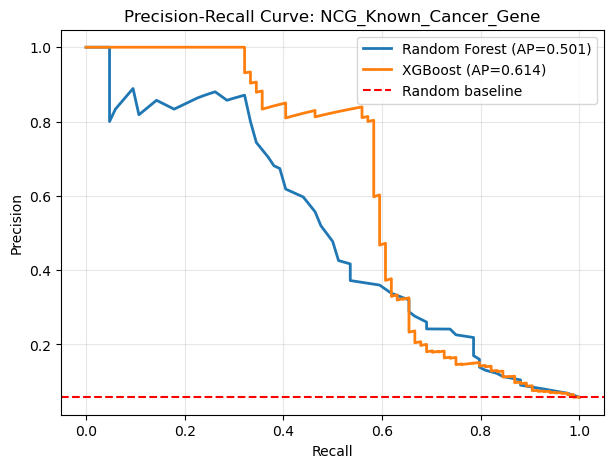

Random Forest - auPRC: 0.501
XGBoost - auPRC: 0.614



In [14]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [15]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    6580
True      654
Name: count, dtype: int64

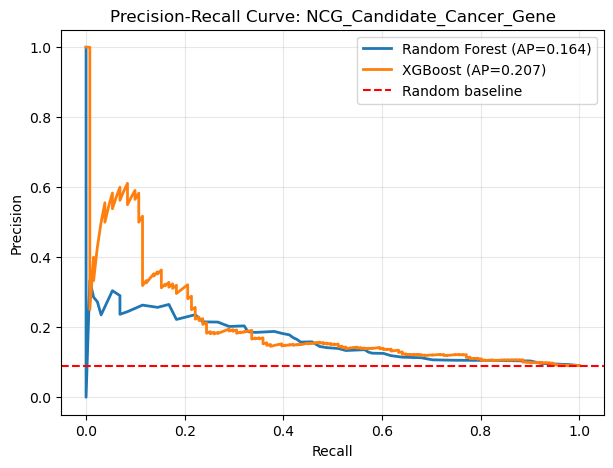

Random Forest - auPRC: 0.164
XGBoost - auPRC: 0.207



In [16]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [17]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    6901
True      333
Name: count, dtype: int64

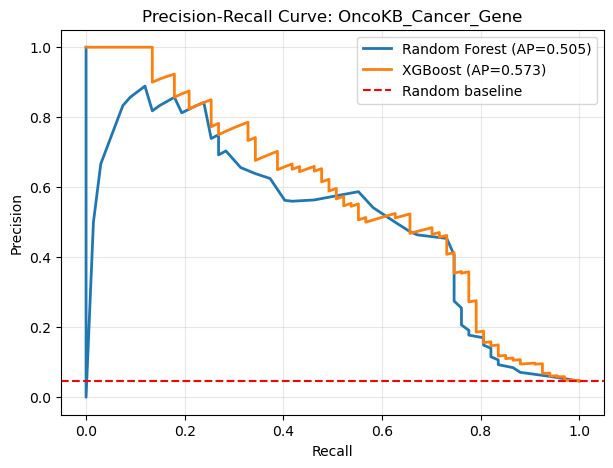

Random Forest - auPRC: 0.505
XGBoost - auPRC: 0.573



In [18]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [19]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    7067
True      167
Name: count, dtype: int64

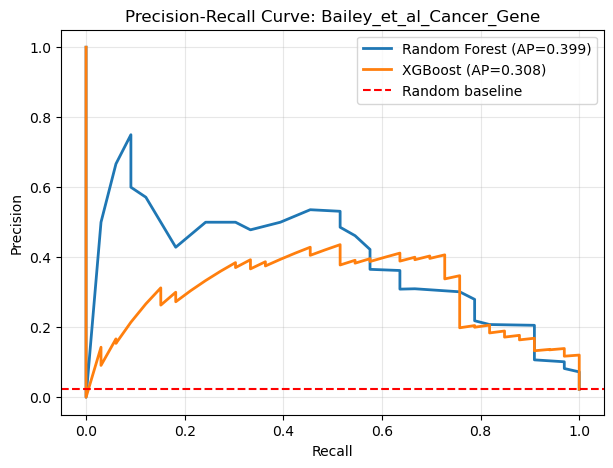

Random Forest - auPRC: 0.399
XGBoost - auPRC: 0.308



In [20]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')